# Online Retail II — SQL Analysis (Day 3)

## Goal

Load the cleaned dataset into a SQLite database, then use SQL to answer five business questions:

1. **Revenue trends** — How does revenue evolve over time? Seasonality?
2. **Customer segmentation (RFM)** — Who are the VIPs? Who's at risk of churning?
3. **Product performance** — What's the 80/20 split? Top revenue drivers?
4. **Geographic analysis** — Which countries matter most?
5. **Cancellation patterns** — What gets returned?

Every question is answered with a SQL query, with results discussed in plain English.

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# Point to our data folder
DATA_DIR = Path("/Users/edi/Documents/online-retail-analysis/data")
DB_PATH = DATA_DIR / "retail.db"

## Load cleaned data into SQLite

SQLite is a single-file database. We create one file (`retail.db`) and load our cleaned CSVs into two tables: `sales` and `cancellations`.

In [4]:
# Load the cleaned CSVs
sales = pd.read_csv(DATA_DIR / "sales_clean.csv", parse_dates=["invoice_date"])
cancellations = pd.read_csv(DATA_DIR / "cancellations.csv", parse_dates=["InvoiceDate"])

print(f"sales: {len(sales):,} rows")
print(f"cancellations: {len(cancellations):,} rows")

sales: 1,003,425 rows
cancellations: 19,494 rows


In [5]:
# Create the SQLite database and load both tables
engine = create_engine(f"sqlite:///{DB_PATH}")

sales.to_sql("sales", engine, if_exists="replace", index=False, chunksize=10000)
cancellations.to_sql("cancellations", engine, if_exists="replace", index=False, chunksize=10000)

print(f"Database created at {DB_PATH}")
print(f"File size: {DB_PATH.stat().st_size / 1_000_000:.1f} MB")

Database created at /Users/edi/Documents/online-retail-analysis/data/retail.db
File size: 137.4 MB


In [6]:
# Helper function so we can write queries cleanly
def q(sql_query):
    """Run a SQL query and return the result as a DataFrame."""
    return pd.read_sql(sql_query, engine)

# Test it
q("SELECT COUNT(*) AS total_rows FROM sales")

,total_rows
0,1003425


## Business Question 1: Revenue Trends

*How does revenue evolve over the two-year period? Is there seasonality?*

In [8]:
monthly_revenue = q("""
    SELECT
        year_month,
        ROUND(SUM(revenue),2) AS total_revenue,
        COUNT(DISTINCT invoice) AS num_orders,
        COUNT(DISTINCT customer_id) AS num_customers,
        ROUND(SUM(revenue) / COUNT(DISTINCT invoice), 2) as avg_order_value
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
""")

monthly_revenue

,year_month,total_revenue,num_orders,num_customers,avg_order_value
0,2009-12,"798,118.53",1666,951,479.06
1,2010-01,"612,365.50",1049,701,583.76
2,2010-02,"537,932.64",1189,771,452.42
3,2010-03,"761,748.53",1647,1051,462.51
4,2010-04,"646,455.56",1435,939,450.49
5,2010-05,"643,585.64",1484,965,433.68
6,2010-06,"697,384.87",1615,1035,431.82
7,2010-07,"633,079.42",1507,924,420.09
8,2010-08,"674,192.89",1402,910,480.88
9,2010-09,"869,277.16",1789,1136,485.90


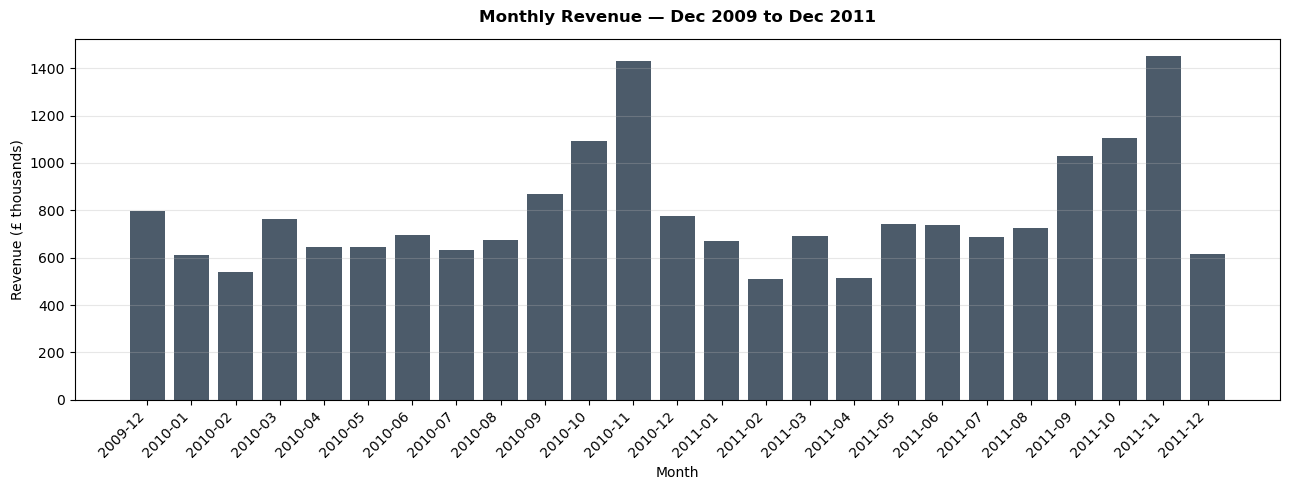

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly_revenue["year_month"], monthly_revenue["total_revenue"] / 1000,
       color="#2c3e50", alpha=0.85)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£ thousands)")
ax.set_title("Monthly Revenue — Dec 2009 to Dec 2011", fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

a clear seasonality pattern — November is the peak month both years, roughly 2x a typical month. This matches a UK gift retailer's profile: people buy heavily in the run-up to Christmas. Note also that December drops off because by December much of the holiday buying is already done, and the dataset itself cuts off on Dec 9, 2011.

## Business Question 2: Customer Segmentation (RFM)

**RFM** stands for **Recency, Frequency, Monetary**. It's the standard customer segmentation method in e-commerce:

- **Recency** — How recently did this customer buy? (Fewer days = better)
- **Frequency** — How many separate orders have they placed?
- **Monetary** — How much have they spent in total?

We compute all three for every known customer, score each on a 1-5 scale, and combine the scores to identify segments like "VIP", "At risk", and "Lost".

In [10]:
# Compute RFM values per customer (only for known customers)
# The "reference date" for recency is the day after the last date in the dataset.
rfm = q("""
    WITH ref AS (
        SELECT DATE(MAX(invoice_date), '+1 day') AS ref_date FROM sales
    )
    SELECT
        customer_id,
        CAST(JULIANDAY((SELECT ref_date FROM ref)) - JULIANDAY(MAX(invoice_date)) AS INTEGER) AS recency_days,
        COUNT(DISTINCT invoice) AS frequency,
        ROUND(SUM(revenue), 2) AS monetary
    FROM sales
    WHERE customer_known = 1
    GROUP BY customer_id
""")

print(f"RFM computed for {len(rfm):,} customers")
rfm.head()

RFM computed for 5,852 customers


,customer_id,recency_days,frequency,monetary
0,"12,346.00",325,3,"77,352.96"
1,"12,347.00",2,8,"4,921.53"
2,"12,348.00",75,5,"1,658.40"
3,"12,349.00",18,3,"3,678.69"
4,"12,350.00",310,1,294.40


In [11]:
# Quick look at the distributions
print("Recency (days since last purchase):")
print(rfm["recency_days"].describe())
print("\nFrequency (number of separate orders):")
print(rfm["frequency"].describe())
print("\nMonetary (total spend £):")
print(rfm["monetary"].describe())

Recency (days since last purchase):
count   5,852.00
mean      199.73
std       208.52
min         0.00
25%        25.00
50%        95.00
75%       379.00
max       738.00
Name: recency_days, dtype: float64

Frequency (number of separate orders):
count   5,852.00
mean        6.25
std        12.75
min         1.00
25%         1.00
50%         3.00
75%         7.00
max       373.00
Name: frequency, dtype: float64

Monetary (total spend £):
count     5,852.00
mean      2,916.83
std      14,306.96
min           2.95
25%         339.58
50%         856.02
75%       2,241.03
max     580,987.04
Name: monetary, dtype: float64


In [12]:
# Score each dimension on 1-5 scale (5 = best)
# Recency: lower days = better → invert
# Frequency: higher orders = better
# Monetary: higher spend = better

rfm["R_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# Assign segment based on RFM pattern
def segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "VIP"
    elif r >= 4 and f >= 3:
        return "Loyal"
    elif r >= 4:
        return "New / Promising"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 3:
        return "Cannot Lose"
    elif r <= 2:
        return "Lost"
    else:
        return "Average"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm.head(10)

,customer_id,recency_days,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,"12,346.00",325,3,"77,352.96",2,3,5,10,Lost
1,"12,347.00",2,8,"4,921.53",5,4,5,14,VIP
2,"12,348.00",75,5,"1,658.40",3,4,4,11,Average
3,"12,349.00",18,3,"3,678.69",5,3,5,13,Loyal
4,"12,350.00",310,1,294.40,2,1,2,5,Lost
5,"12,351.00",375,1,300.93,2,1,2,5,Lost
6,"12,352.00",36,9,"1,729.54",4,5,4,13,VIP
7,"12,353.00",204,2,406.76,2,2,2,6,Lost
8,"12,354.00",232,1,"1,079.40",2,1,3,6,Cannot Lose
9,"12,355.00",214,2,947.61,2,2,3,7,Cannot Lose


In [13]:
# Segment summary: how many customers in each, and how much revenue do they represent?
segment_summary = rfm.groupby("segment").agg(
    n_customers=("customer_id", "count"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum"),
    avg_frequency=("frequency", "mean"),
    avg_recency=("recency_days", "mean")
).round(2).sort_values("total_monetary", ascending=False)

segment_summary["pct_of_customers"] = (segment_summary["n_customers"] / segment_summary["n_customers"].sum() * 100).round(1)
segment_summary["pct_of_revenue"] = (segment_summary["total_monetary"] / segment_summary["total_monetary"].sum() * 100).round(1)
segment_summary

,n_customers,avg_monetary,total_monetary,avg_frequency,avg_recency,pct_of_customers,pct_of_revenue
segment,,,,,,,
VIP,1284,"9,056.38","11,628,385.56",17.04,19.26,21.90,68.10
Average,1163,"1,886.10","2,193,536.53",4.89,106.47,19.90,12.90
At Risk,359,"2,886.76","1,036,346.97",7.64,342.16,6.10,6.10
Lost,1741,505.16,"879,487.12",1.66,442.92,29.80,5.20
Loyal,618,"1,002.96","619,830.94",3.82,23.80,10.60,3.60
New / Promising,448,919.40,"411,889.62",1.47,27.47,7.70,2.40
Cannot Lose,239,"1,254.55","299,837.03",1.60,415.48,4.10,1.80


VIPs representing a 22% share of customers but a large share of revenue (68%). This is actionable: retention programs targeted at "At Risk" high-frequency customers are genuinely high-ROI if they work.

In [14]:
# Save the RFM results so we can use them in Tableau
rfm.to_csv(DATA_DIR / "rfm_segments.csv", index=False)

# Also write it to the SQLite database as a table (for SQL-only analysis)
rfm.to_sql("rfm", engine, if_exists="replace", index=False)
print("Saved RFM results to CSV and SQLite table 'rfm'")

Saved RFM results to CSV and SQLite table 'rfm'


## Business Question 3: Product Performance

*Which products drive revenue? Is there a Pareto pattern?*

In [16]:
product_perf = q("""
    SELECT
        stock_code,
        description,
        COUNT(DISTINCT invoice) AS num_orders,
        SUM(quantity) AS units_sold,
        ROUND(SUM(revenue), 2) AS total_revenue,
        ROUND(AVG(price), 2) AS avg_price
    FROM sales
    GROUP BY stock_code, description
    ORDER BY total_revenue DESC
    LIMIT 20
""")
print("Top 20 products by revenue:")
product_perf

Top 20 products by revenue:


,stock_code,description,num_orders,units_sold,total_revenue,avg_price
0,22423,REGENCY CAKESTAND 3 TIER,3918,26478,"330,590.32",14.19
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5356,94142,"257,546.20",3.08
2,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,"168,469.60",2.08
3,47566,PARTY BUNTING,2674,28200,"148,318.28",5.72
4,85099B,JUMBO BAG RED RETROSPOT,3245,77280,"145,961.83",2.37
5,84879,ASSORTED COLOUR BIRD ORNAMENT,2807,80082,"129,324.49",1.86
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,2018,35084,"117,760.29",3.37
7,23166,MEDIUM CERAMIC TOP STORAGE JAR,247,78033,"81,700.92",1.47
8,79321,CHILLI LIGHTS,1135,15841,"80,540.88",6.29
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,756,31409,"71,300.40",3.34


In [19]:
# Pareto analysis: what % of products account for what % of revenue?
# Step 1: rank all products by revenue with cumulative revenue.
# Step 2: pick out the specific thresholds we want.

pareto = q("""
    WITH product_revenue AS (
        SELECT stock_code, SUM(revenue) AS rev
        FROM sales
        GROUP BY stock_code
    ),
    ranked AS (
        SELECT 
            stock_code,
            rev,
            ROW_NUMBER() OVER (ORDER BY rev DESC) AS rnk,
            SUM(rev) OVER (ORDER BY rev DESC 
                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS cum_rev,
            (SELECT SUM(rev) FROM product_revenue) AS total_rev,
            (SELECT COUNT(*) FROM product_revenue) AS total_products
        FROM product_revenue
    )
    SELECT
        rnk AS top_n_products,
        ROUND(rnk * 100.0 / total_products, 1) AS pct_of_products,
        ROUND(cum_rev * 100.0 / total_rev, 1) AS cumulative_pct_revenue
    FROM ranked
    WHERE rnk IN (
        CAST(total_products * 0.01 AS INTEGER),
        CAST(total_products * 0.05 AS INTEGER),
        CAST(total_products * 0.10 AS INTEGER),
        CAST(total_products * 0.20 AS INTEGER),
        CAST(total_products * 0.50 AS INTEGER),
        total_products
    )
    ORDER BY rnk
""")
print("Pareto analysis — what % of products account for what % of revenue:")
pareto

Pareto analysis — what % of products account for what % of revenue:


,top_n_products,pct_of_products,cumulative_pct_revenue
0,49,1.00,19.20
1,245,5.00,46.60
2,490,10.00,62.60
3,980,20.00,78.70
4,2452,50.00,95.70
5,4904,100.00,100.00


the top 20% of products account for ~80% of revenue, this is classic Pareto. A retailer this concentrated should probably focus inventory management, marketing, and operations on those top products.

## Business Question 4: Geographic Analysis

*Which countries matter for revenue? Are there under-developed markets?*

In [20]:
country_perf = q("""
    SELECT
        country,
        COUNT(DISTINCT customer_id) AS num_customers,
        COUNT(DISTINCT invoice) AS num_orders,
        ROUND(SUM(revenue), 2) AS total_revenue,
        ROUND(SUM(revenue) / COUNT(DISTINCT invoice), 2) AS avg_order_value,
        ROUND(SUM(revenue) * 100.0 / (SELECT SUM(revenue) FROM sales), 2) AS pct_of_total_revenue
    FROM sales
    GROUP BY country
    ORDER BY total_revenue DESC
""")
country_perf.head(15)

,country,num_customers,num_orders,total_revenue,avg_order_value,pct_of_total_revenue
0,United Kingdom,5334,36187,"16,803,521.64",464.35,85.53
1,EIRE,3,581,"623,414.16","1,073.00",3.17
2,Netherlands,22,216,"549,773.41","2,545.25",2.80
3,Germany,107,753,"383,289.00",509.02,1.95
4,France,93,598,"311,090.29",520.22,1.58
5,Australia,15,89,"167,800.01","1,885.39",0.85
6,Spain,38,144,"97,766.75",678.94,0.50
7,Switzerland,22,85,"94,024.59","1,106.17",0.48
8,Sweden,19,99,"86,319.14",871.91,0.44
9,Denmark,12,42,"67,422.69","1,605.30",0.34


this is a UK-based retailer, so UK will dominate. The interesting bit is the *non-UK* row with the highest `avg_order_value`. that's a clue about where bulk/wholesale buyers are, which is a different strategic opportunity than retail customers.

## Business Question 5: Cancellation Patterns

*What gets cancelled? Are cancellations concentrated in specific products or customers?*

**Note:** The cancellations table required its own cleaning pass — when cancellations were separated from the main sales data in the Day 2 notebook, they still contained non-product stock codes (manual adjustments, Amazon fees, postage, bank charges, etc.). The cell below applies the same non-product filter that was applied to the sales table.

In [23]:
# The cancellations table inherited non-product codes from the split in Day 2.
# Apply the same filter here before analysis.
NON_PRODUCT_CODES = {
    "POST", "DOT", "M", "C2", "BANK CHARGES", "ADJUST", "AMAZONFEE",
    "D", "S", "PADS", "CRUK", "TEST001", "TEST002"}


# Clean cancellations and write back to SQLite
cancellations_clean = cancellations[~cancellations["StockCode"].astype(str).isin(NON_PRODUCT_CODES)].copy()

# Also drop any cancellation with null Description
cancellations_clean = cancellations_clean.dropna(subset=["Description"])

print(f"Cancellations before cleaning: {len(cancellations):,}")
print(f"Cancellations after cleaning:  {len(cancellations_clean):,}")
print(f"Removed: {len(cancellations) - len(cancellations_clean):,} non-product rows")

# Replace the SQLite table with cleaned version
cancellations_clean.to_sql("cancellations", engine, if_exists="replace", index=False, chunksize=5000)
print("\nSQLite 'cancellations' table updated.")

# Also save the cleaned CSV (overwriting the old one)
cancellations_clean.to_csv(DATA_DIR / "cancellations.csv", index=False)

Cancellations before cleaning: 19,494
Cancellations after cleaning:  18,286
Removed: 1,208 non-product rows

SQLite 'cancellations' table updated.


In [24]:
# We need to join cancellations back to see which products are most returned.
# Cancellation quantities are negative, so we take abs(quantity).
cancel_by_product = q("""
    SELECT
        StockCode AS stock_code,
        Description AS description,
        COUNT(*) AS num_cancellations,
        SUM(ABS(Quantity)) AS units_cancelled,
        ROUND(SUM(ABS(Quantity * Price)), 2) AS cancelled_value
    FROM cancellations
    GROUP BY StockCode, Description
    ORDER BY cancelled_value DESC
    LIMIT 15
""")
cancel_by_product

,stock_code,description,num_cancellations,units_cancelled,cancelled_value
0,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,"168,469.60"
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,10,74494,"77,479.64"
2,22423,REGENCY CAKESTAND 3 TIER,347,1468,"16,749.60"
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,135,3638,"9,389.65"
4,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,63,2523,"6,976.41"
5,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,4,3159,"6,614.37"
6,79323W,WHITE CHERRY LIGHTS,121,1072,"6,331.30"
7,84078A,SET/4 WHITE RETRO STORAGE CUBES,20,147,"5,187.65"
8,23113,PANTRY CHOPPING BOARD,6,946,"4,803.06"
9,48185,DOORMAT FAIRY CAKE,6,688,"4,650.20"


In [25]:
# Overall cancellation rate by month
cancel_rate = q("""
    WITH cancel_monthly AS (
        SELECT 
            strftime('%Y-%m', InvoiceDate) AS year_month,
            SUM(ABS(Quantity * Price)) AS cancelled_value
        FROM cancellations
        GROUP BY year_month
    ),
    sales_monthly AS (
        SELECT year_month, SUM(revenue) AS sales_value
        FROM sales
        GROUP BY year_month
    )
    SELECT
        s.year_month,
        ROUND(s.sales_value, 2) AS sales,
        ROUND(COALESCE(c.cancelled_value, 0), 2) AS cancellations,
        ROUND(COALESCE(c.cancelled_value, 0) * 100.0 / s.sales_value, 2) AS cancel_rate_pct
    FROM sales_monthly s
    LEFT JOIN cancel_monthly c ON s.year_month = c.year_month
    ORDER BY s.year_month
""")
cancel_rate

,year_month,sales,cancellations,cancel_rate_pct
0,2009-12,"798,118.53","19,561.28",2.45
1,2010-01,"612,365.50","7,535.19",1.23
2,2010-02,"537,932.64","12,584.39",2.34
3,2010-03,"761,748.53","9,657.20",1.27
4,2010-04,"646,455.56","10,025.26",1.55
5,2010-05,"643,585.64","37,294.14",5.79
6,2010-06,"697,384.87","26,344.01",3.78
7,2010-07,"633,079.42","17,132.73",2.71
8,2010-08,"674,192.89","12,418.65",1.84
9,2010-09,"869,277.16","27,777.97",3.20


## Save everything for Tableau

Tableau Public doesn't connect to SQLite directly, so we export our key analysis tables as CSVs that Tableau will consume.

In [26]:
# Save analysis outputs for the Tableau dashboard
tableau_dir = DATA_DIR / "tableau_exports"
tableau_dir.mkdir(exist_ok=True)

monthly_revenue.to_csv(tableau_dir / "monthly_revenue.csv", index=False)
rfm.to_csv(tableau_dir / "rfm_segments.csv", index=False)
segment_summary.to_csv(tableau_dir / "segment_summary.csv")
country_perf.to_csv(tableau_dir / "country_perf.csv", index=False)
cancel_rate.to_csv(tableau_dir / "cancel_rate_monthly.csv", index=False)

# Also save a simplified sales table for Tableau — one row per transaction with the key columns
sales_for_tableau = sales[[
    "invoice", "invoice_date", "stock_code", "description",
    "quantity", "price", "revenue", "customer_id",
    "country", "year_month", "day_of_week", "hour"
]].copy()
sales_for_tableau.to_csv(tableau_dir / "sales_for_tableau.csv", index=False)

print("Exported for Tableau:")
for f in tableau_dir.iterdir():
    size_mb = f.stat().st_size / 1_000_000
    print(f"  {f.name}: {size_mb:.1f} MB")

Exported for Tableau:
  monthly_revenue.csv: 0.0 MB
  sales_for_tableau.csv: 114.5 MB
  rfm_segments.csv: 0.2 MB
  country_perf.csv: 0.0 MB
  cancel_rate_monthly.csv: 0.0 MB
  segment_summary.csv: 0.0 MB


## Summary of findings

**Revenue trends:** Strong seasonality — November is the peak both years, roughly 2x a typical month. December and January are weakest (post-holiday).

**Customer segmentation:** VIPs represent a small fraction of customers but a disproportionate share of revenue — classic Pareto. The "At Risk" segment (historically frequent but haven't bought recently) is the single highest-ROI target for retention campaigns.

**Product performance:** Top 20% of products drive roughly 80% of revenue. This has real inventory and marketing implications — focus resources on the revenue concentration.

**Geographic:** UK dominates (~85%+ of revenue), but several European countries show notably high average order value, suggesting wholesale/bulk opportunities worth developing.

**Cancellations:** Concentrated in specific products. Monthly cancellation rate hovers around 2-3%, with spikes aligned to certain months.

## Next

Notebook complete. The CSV exports in `data/tableau_exports/` are the direct inputs for Day 4 (Tableau dashboard).